In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [2]:
np.random.seed(42)
n = 5000

data = pd.DataFrame({
    'customer_id': [f'C{i:05d}' for i in range(n)],
    'tenure_months': np.random.randint(1, 72, n),
    'monthly_spend': np.round(np.random.exponential(120, n), 2),
    'num_support_tickets': np.random.poisson(1.5, n),
    'last_login_days_ago': np.random.randint(0, 90, n),
    'feature_adoption_score': np.round(np.random.beta(2, 5, n), 3),
    'plan_type': np.random.choice(
        ['Free', 'Starter', 'Pro', 'Enterprise'],
        n,
        p=[0.4, 0.3, 0.2, 0.1]
    ),
    'contract_type': np.random.choice(
        ['Month-to-Month', 'Annual', 'Two-Year'],
        n,
        p=[0.5, 0.35, 0.15]
    ),
    'region': np.random.choice(
        ['NA', 'EMEA', 'APAC', 'LATAM'],
        n
    ),
    'has_referral': np.random.choice(
        [True, False],
        n,
        p=[0.3, 0.7]
    ),
    'num_integrations': np.random.randint(0, 15, n),
})

churn_prob = (
    0.4
    - 0.005 * data.tenure_months
    + 0.003 * data.num_support_tickets
    + 0.004 * data.last_login_days_ago
    - 0.3 * data.feature_adoption_score
).clip(0.05, 0.95)

data['churned'] = (np.random.rand(n) < churn_prob).astype(int)

data.to_csv('churn_data.csv', index=False)


In [3]:
data.dtypes

customer_id                object
tenure_months               int64
monthly_spend             float64
num_support_tickets         int64
last_login_days_ago         int64
feature_adoption_score    float64
plan_type                  object
contract_type              object
region                     object
has_referral                 bool
num_integrations            int64
churned                     int64
dtype: object

In [4]:
data.head(5)

,customer_id,tenure_months,monthly_spend,num_support_tickets,last_login_days_ago,feature_adoption_score,plan_type,contract_type,region,has_referral,num_integrations,churned
0,C00000,52,615.56,2,36,0.469,Starter,Month-to-Month,NA,False,13,0
1,C00001,15,1.34,2,48,0.401,Free,Month-to-Month,EMEA,False,3,1
2,C00002,61,157.20,0,77,0.016,Enterprise,Month-to-Month,LATAM,True,2,0
3,C00003,21,101.78,0,89,0.342,Pro,Month-to-Month,APAC,True,11,0
4,C00004,24,68.31,1,49,0.118,Pro,Month-to-Month,NA,False,4,0


In [5]:
print(data["churned"].value_counts())
print(data["churned"].value_counts(normalize = True))

churned
0    3388
1    1612
Name: count, dtype: int64
churned
0    0.6776
1    0.3224
Name: proportion, dtype: float64


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   tenure_months           5000 non-null   int64  
 2   monthly_spend           5000 non-null   float64
 3   num_support_tickets     5000 non-null   int64  
 4   last_login_days_ago     5000 non-null   int64  
 5   feature_adoption_score  5000 non-null   float64
 6   plan_type               5000 non-null   object 
 7   contract_type           5000 non-null   object 
 8   region                  5000 non-null   object 
 9   has_referral            5000 non-null   bool   
 10  num_integrations        5000 non-null   int64  
 11  churned                 5000 non-null   int64  
dtypes: bool(1), float64(2), int64(5), object(4)
memory usage: 434.7+ KB


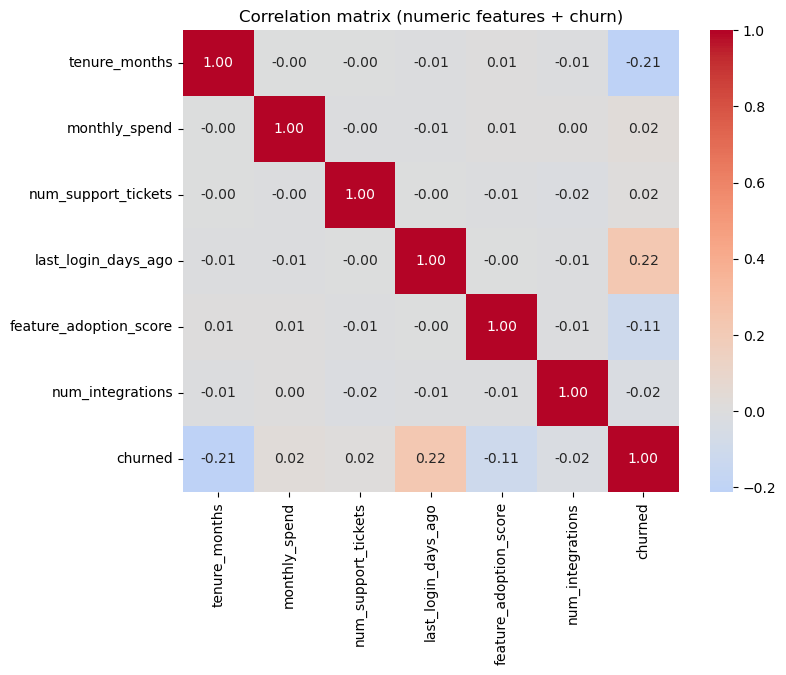

In [7]:
num_cols = [
    'tenure_months', 'monthly_spend', 'num_support_tickets',
    'last_login_days_ago', 'feature_adoption_score', 'num_integrations'
]
corr_matrix = data[num_cols + ['churned']].corr()
#print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)
plt.title('Correlation matrix (numeric features + churn)')
plt.show()

tenure_months            -0.212669
feature_adoption_score   -0.112977
num_integrations         -0.024080
num_support_tickets       0.019365
monthly_spend             0.024980
last_login_days_ago       0.219635
Name: churned, dtype: float64


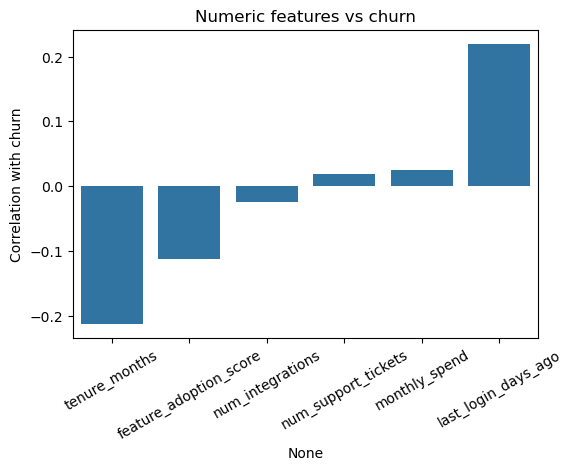

In [8]:
churn_corr = corr_matrix['churned'].drop('churned').sort_values()
print(churn_corr)
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_corr.index, y=churn_corr.values)
plt.xticks(rotation=30)
plt.ylabel('Correlation with churn')
plt.title('Numeric features vs churn')
plt.show()

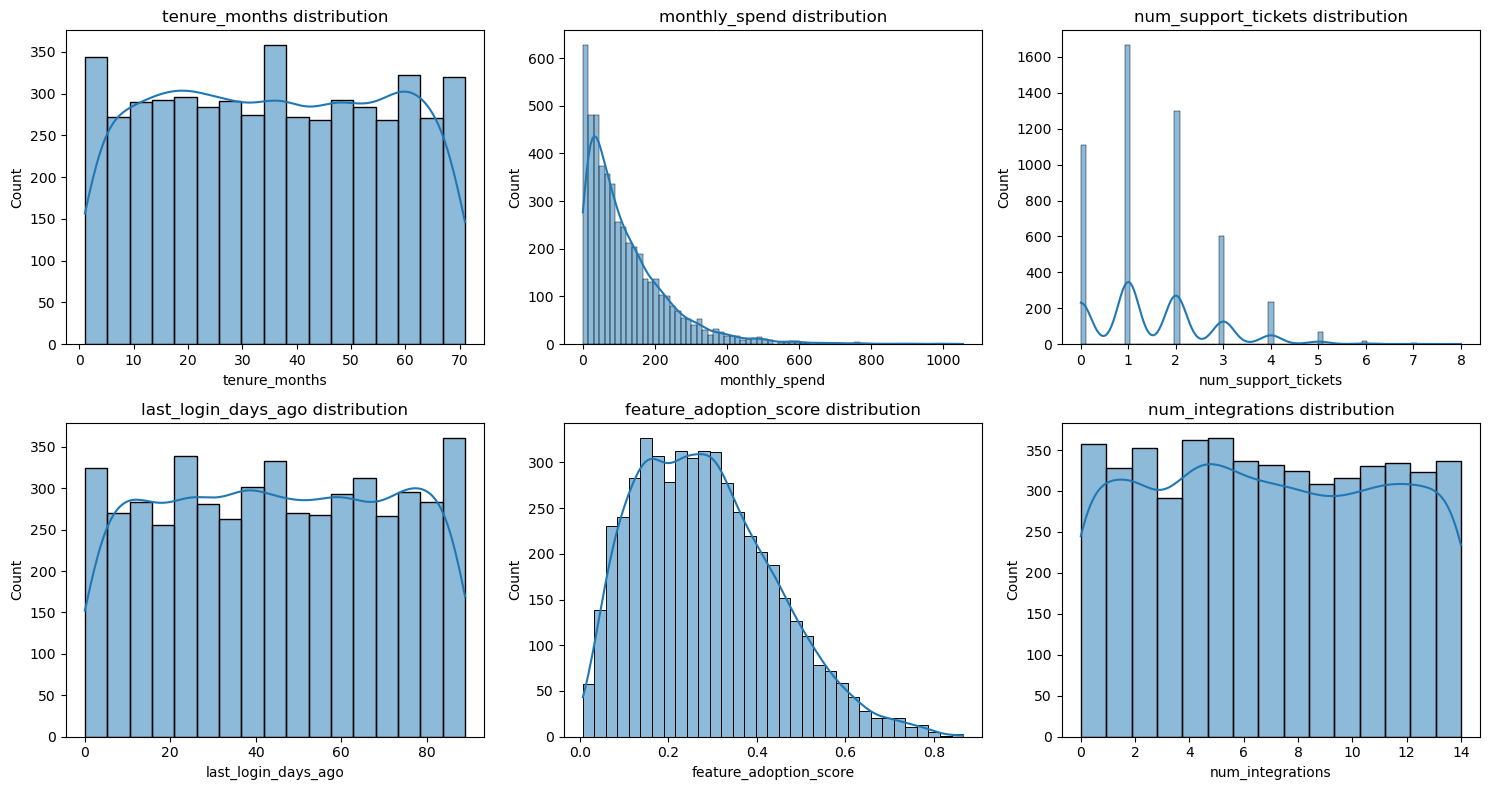

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

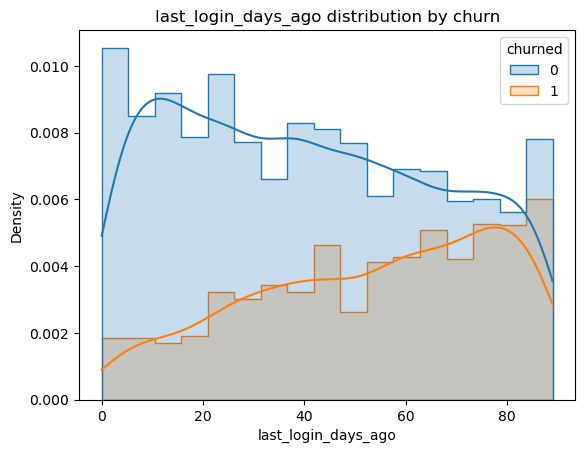

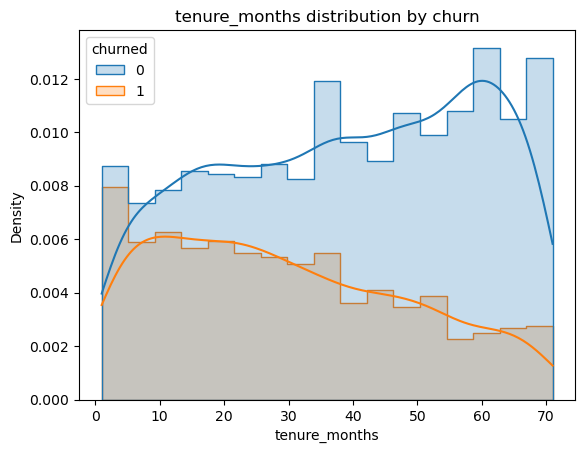

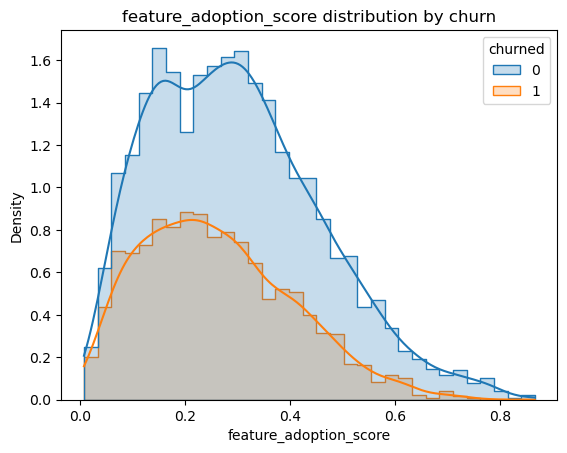

In [10]:
key_cols = ['last_login_days_ago', 'tenure_months', 'feature_adoption_score']

for col in key_cols:
    sns.histplot(data=data, x=col, hue='churned', kde=True, stat='density', element='step')
    plt.title(f'{col} distribution by churn')
    plt.show()

In [11]:
data['inactive_30_plus'] = (
    data['last_login_days_ago'] > 30
).astype(int)

data['engagement_score'] = (
    data['feature_adoption_score'] /
    (data['last_login_days_ago'] + 1)
)
data['support_per_month'] = (
    data['num_support_tickets'] /
    (data['tenure_months'] + 1)
)
data['high_value_customer'] = (
    (data['monthly_spend'] > data['monthly_spend'].median()) &
    (data['plan_type'].isin(['Pro', 'Enterprise']))
).astype(int)


engineered_cols = [
    'engagement_score',
    'support_per_month',
    'high_value_customer',
    'inactive_30_plus'
]

for col in engineered_cols:
    print(col)
    print(data.groupby('churned')[col].describe())
    print()

engagement_score
          count      mean       std       min       25%       50%       75%  \
churned                                                                       
0        3388.0  0.018712  0.042103  0.000122  0.003853  0.007054  0.015087   
1        1612.0  0.008471  0.017789  0.000104  0.002699  0.004551  0.007659   

           max  
churned         
0        0.557  
1        0.300  

support_per_month
          count      mean       std  min       25%       50%       75%  \
churned                                                                  
0        3388.0  0.069412  0.139708  0.0  0.014706  0.032787  0.068966   
1        1612.0  0.106910  0.201653  0.0  0.018182  0.046154  0.111111   

              max  
churned            
0        2.000000  
1        2.666667  

high_value_customer
          count      mean       std  min  25%  50%  75%  max
churned                                                     
0        3388.0  0.147285  0.354442  0.0  0.0  0.0  0.0  1.

In [12]:
data.head(5)

,customer_id,tenure_months,monthly_spend,num_support_tickets,last_login_days_ago,feature_adoption_score,plan_type,contract_type,region,has_referral,num_integrations,churned,inactive_30_plus,engagement_score,support_per_month,high_value_customer
0,C00000,52,615.56,2,36,0.469,Starter,Month-to-Month,NA,False,13,0,1,0.012676,0.037736,0
1,C00001,15,1.34,2,48,0.401,Free,Month-to-Month,EMEA,False,3,1,1,0.008184,0.125000,0
2,C00002,61,157.20,0,77,0.016,Enterprise,Month-to-Month,LATAM,True,2,0,1,0.000205,0.000000,1
3,C00003,21,101.78,0,89,0.342,Pro,Month-to-Month,APAC,True,11,0,1,0.003800,0.000000,1
4,C00004,24,68.31,1,49,0.118,Pro,Month-to-Month,NA,False,4,0,1,0.002360,0.040000,0


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   tenure_months           5000 non-null   int64  
 2   monthly_spend           5000 non-null   float64
 3   num_support_tickets     5000 non-null   int64  
 4   last_login_days_ago     5000 non-null   int64  
 5   feature_adoption_score  5000 non-null   float64
 6   plan_type               5000 non-null   object 
 7   contract_type           5000 non-null   object 
 8   region                  5000 non-null   object 
 9   has_referral            5000 non-null   bool   
 10  num_integrations        5000 non-null   int64  
 11  churned                 5000 non-null   int64  
 12  inactive_30_plus        5000 non-null   int64  
 13  engagement_score        5000 non-null   float64
 14  support_per_month       5000 non-null   

In [14]:
data.drop(columns=['customer_id'], inplace=True)

In [15]:
target_col = 'churned'
numeric_features = [
    'tenure_months',
    'monthly_spend',
    'num_support_tickets',
    'last_login_days_ago',
    'feature_adoption_score',
    'num_integrations',
    'engagement_score',
    'support_per_month',
    'inactive_30_plus',
    'has_referral',
    'high_value_customer'
]

categorical_features = [
    'plan_type',
    'contract_type',
    'region'
]

X = data[numeric_features + categorical_features]
y = data[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)



In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [17]:
log_reg_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1,
        solver='lbfgs'
    ))
])

# Fit on train
log_reg_clf.fit(X_train, y_train)

# Evaluate on validation
y_val_proba = log_reg_clf.predict_proba(X_val)[:, 1]
y_val_pred = log_reg_clf.predict(X_val)

print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("Validation confusion matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation classification report:\n", classification_report(y_val, y_val_pred))


Validation ROC-AUC: 0.6696899199583524
Validation confusion matrix:
 [[313 195]
 [ 82 160]]
Validation classification report:
               precision    recall  f1-score   support

           0       0.79      0.62      0.69       508
           1       0.45      0.66      0.54       242

    accuracy                           0.63       750
   macro avg       0.62      0.64      0.61       750
weighted avg       0.68      0.63      0.64       750



In [18]:
rf_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

rf_clf.fit(X_train, y_train)

y_val_proba_rf = rf_clf.predict_proba(X_val)[:, 1]
y_val_pred_rf = rf_clf.predict(X_val)

print("RF Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba_rf))
print("RF Validation confusion matrix:\n", confusion_matrix(y_val, y_val_pred_rf))
print("RF Validation classification report:\n", classification_report(y_val, y_val_pred_rf))

RF Validation ROC-AUC: 0.6459499251643132
RF Validation confusion matrix:
 [[452  56]
 [188  54]]
RF Validation classification report:
               precision    recall  f1-score   support

           0       0.71      0.89      0.79       508
           1       0.49      0.22      0.31       242

    accuracy                           0.67       750
   macro avg       0.60      0.56      0.55       750
weighted avg       0.64      0.67      0.63       750



In [19]:
xgb_plain_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        random_state=42
    ))
])

xgb_plain_clf.fit(X_train, y_train)

y_val_proba_xgb_plain = xgb_plain_clf.predict_proba(X_val)[:, 1]
y_val_pred_xgb_plain = xgb_plain_clf.predict(X_val)

print("Plain XGB Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba_xgb_plain))
print("Plain XGB Validation confusion matrix:\n", confusion_matrix(y_val, y_val_pred_xgb_plain))
print("Plain XGB Validation classification report:\n", classification_report(y_val, y_val_pred_xgb_plain))

Plain XGB Validation ROC-AUC: 0.6243329862692784
Plain XGB Validation confusion matrix:
 [[414  94]
 [157  85]]
Plain XGB Validation classification report:
               precision    recall  f1-score   support

           0       0.73      0.81      0.77       508
           1       0.47      0.35      0.40       242

    accuracy                           0.67       750
   macro avg       0.60      0.58      0.59       750
weighted avg       0.64      0.67      0.65       750



In [20]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)

X_train_proc = X_train_proc.toarray() if hasattr(X_train_proc, 'toarray') else X_train_proc
X_val_proc = X_val_proc.toarray() if hasattr(X_val_proc, 'toarray') else X_val_proc

y_train_np = y_train.values.astype(np.float32)
y_val_np = y_val.values.astype(np.float32)

X_train_proc.shape, X_val_proc.shape

((3500, 22), (750, 22))

In [21]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

input_dim = X_train_proc.shape[1]

class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = ChurnNN(input_dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        y_proba = model(X_tensor).squeeze().cpu().numpy()
    y_pred = (y_proba >= 0.5).astype(int)
    auc = roc_auc_score(y_tensor.cpu().numpy(), y_proba)
    print("ROC-AUC:", auc)
    print("Confusion matrix:\n", confusion_matrix(y_tensor.cpu().numpy(), y_pred))
    print("Classification report:\n", classification_report(y_tensor.cpu().numpy(), y_pred))
    return auc

n_epochs = 20

for epoch in range(1, n_epochs + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_hat = model(xb).squeeze()
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, train loss: {epoch_loss:.4f}")
        print("Validation metrics:")
        evaluate(model, X_val_tensor, y_val_tensor)
        print("-" * 40)

Epoch 5, train loss: 0.5635
Validation metrics:
ROC-AUC: 0.6699176807444523
Confusion matrix:
 [[448  60]
 [188  54]]
Classification report:
               precision    recall  f1-score   support

         0.0       0.70      0.88      0.78       508
         1.0       0.47      0.22      0.30       242

    accuracy                           0.67       750
   macro avg       0.59      0.55      0.54       750
weighted avg       0.63      0.67      0.63       750

----------------------------------------
Epoch 10, train loss: 0.5526
Validation metrics:
ROC-AUC: 0.6681769375935446
Confusion matrix:
 [[435  73]
 [178  64]]
Classification report:
               precision    recall  f1-score   support

         0.0       0.71      0.86      0.78       508
         1.0       0.47      0.26      0.34       242

    accuracy                           0.67       750
   macro avg       0.59      0.56      0.56       750
weighted avg       0.63      0.67      0.63       750

--------------------